In [57]:
import next_gen_scrapy as ngs
import nflreadpy as nfl
import pandas as pd

In [58]:
data = nfl.load_ftn_charting(seasons=[2026])

In [59]:
pbp = nfl.load_pbp(seasons=[2026])

In [60]:
pbp_pd = pbp.to_pandas()
data_pd = data.to_pandas()

data_pd["nflverse_play_id"] = data_pd["nflverse_play_id"].astype("float64")

merged = pbp_pd.merge(
    data_pd,
    left_on=["game_id", "play_id"],
    right_on=["nflverse_game_id", "nflverse_play_id"],
    how="left",
)

In [61]:
merged

,play_id,game_id,old_game_id,home_team,away_team,season_type,week_x,posteam,posteam_type,defteam,...,read_thrown,is_catchable_ball,is_contested_ball,is_created_reception,is_drop,is_qb_sneak,n_blitzers,n_pass_rushers,is_qb_fault_sack,date_pulled
0,1.0,2026_01_ARI_LAC,2026091308,LAC,ARI,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,39.0,2026_01_ARI_LAC,2026091308,LAC,ARI,REG,1,ARI,away,LAC,...,0,False,False,False,False,False,0.0,0.0,False,2026-09-18 15:48:10.234941+00:00
2,62.0,2026_01_ARI_LAC,2026091308,LAC,ARI,REG,1,ARI,away,LAC,...,1,True,True,False,False,False,0.0,4.0,False,2026-09-18 15:48:10.234941+00:00
3,87.0,2026_01_ARI_LAC,2026091308,LAC,ARI,REG,1,ARI,away,LAC,...,0,False,False,False,False,False,0.0,0.0,False,2026-09-18 15:48:10.234941+00:00
4,109.0,2026_01_ARI_LAC,2026091308,LAC,ARI,REG,1,ARI,away,LAC,...,1,True,False,False,True,False,1.0,5.0,False,2026-09-18 15:48:10.234941+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5484,4117.0,2026_02_WAS_DAL,2026092011,DAL,WAS,REG,2,WAS,away,DAL,...,0,False,False,False,False,False,0.0,0.0,False,2026-09-22 05:01:25.151968+00:00
5485,4159.0,2026_02_WAS_DAL,2026092011,DAL,WAS,REG,2,WAS,away,DAL,...,0,False,False,False,False,False,0.0,0.0,False,2026-09-22 05:01:25.151968+00:00
5486,4188.0,2026_02_WAS_DAL,2026092011,DAL,WAS,REG,2,WAS,away,DAL,...,0,False,False,False,False,False,0.0,0.0,False,2026-09-22 05:01:25.151968+00:00
5487,4210.0,2026_02_WAS_DAL,2026092011,DAL,WAS,REG,2,WAS,away,DAL,...,0,False,False,False,False,False,0.0,0.0,False,2026-09-22 05:01:25.151968+00:00


In [62]:
# overall match rate
n_total = len(merged)
n_matched = merged["nflverse_play_id"].notna().sum()
print(f"pbp rows: {n_total}")
print(f"matched to FTN charting: {n_matched} ({n_matched/n_total:.1%})")
print(f"unmatched: {n_total - n_matched}")

# did the join fan out any pbp rows? (nflverse_play_id should be unique per game)
dupe_check = data_pd.groupby(["nflverse_game_id", "nflverse_play_id"]).size()
print(f"\nduplicate (game_id, play_id) keys in FTN data: {(dupe_check > 1).sum()}")
print(f"merged row count vs pbp row count: {len(merged)} vs {len(pbp_pd)}")

# sanity check: unmatched plays — what play types are they?
unmatched = merged[merged["nflverse_play_id"].isna()]
print("\nplay_type breakdown of unmatched rows:")
print(unmatched["play_type"].value_counts(dropna=False))


pbp rows: 5489
matched to FTN charting: 5174 (94.3%)
unmatched: 315

duplicate (game_id, play_id) keys in FTN data: 0
merged row count vs pbp row count: 5489 vs 5489

play_type breakdown of unmatched rows:
play_type
NaN            165
pass            65
run             46
no_play         11
punt             9
kickoff          8
extra_point      4
field_goal       3
qb_kneel         3
qb_spike         1
Name: count, dtype: int64


In [54]:
passes = ngs.get_passes("Bryce Young", 2026, [1,2])

looking up 2026 pass charts for Bryce Young, weeks 1, 2...
  downloading 2 Bryce Young
  downloading 1 Bryce Young


In [39]:
routes = ngs.get_routes("George Kittle", 2026, [1,2])

looking up 2026 route charts for George Kittle, weeks 1, 2...
  downloading 2 George Kittle


/Users/ryan/Downloads/FF-Python-Analytics-master/next_gen_scrapy/player.py:71: UserWarning: no route chart found for 'George Kittle' in 2026, week(s): 1
  warnings.warn("no %s chart found for %r in %s, week(s): %s"


In [63]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def draw_field(ax, ymin=-10, ymax=40):
    """Simple top-down field: sidelines, LOS, 5-yd lines, hash marks. x in yards, y = yards past LOS."""
    ymin, ymax = int(math.floor(ymin)), int(math.ceil(ymax))          # range() needs ints
    ax.set_facecolor('black')                                        # black field, so heatmap colors (inferno etc.) read cleanly
    for y in range(ymin - ymin % 5, ymax + 1, 5):
        ax.axhline(y, color='white', alpha=0.25, lw=0.8)
    ax.axhline(0, color='#2f6bff', lw=2.5, zorder=1)                 # line of scrimmage
    for x in (-26.67, 26.67):
        ax.axvline(x, color='white', lw=1.5)                          # sidelines
    for x in (-3.08, 3.08):
        ax.axvline(x, color='white', alpha=0.25, lw=0.8, ls=':')     # hashes
    ax.set_xlim(-30, 30)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.set_xlabel('x (yards)')
    ax.set_ylabel('yards past line of scrimmage')


def count(data, id_col):
    """Number of routes/carries in `data`. The ids restart at 1 every game, so count (game_id, id) pairs."""
    return data.groupby(['game_id', id_col]).ngroups


# ---------------------------------------------------------------- routes
ROUTE_STYLE = {'COMPLETE': dict(color='white', lw=2, alpha=0.9),
               'INCOMPLETE': dict(color='#9aa0a6', lw=1.5, alpha=0.8, ls='--')}

def plot_routes(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymax=max(30, data['y_coord'].max() + 3))
    for _, r in data.groupby(['game_id', 'route_id']):              # one line per route per game
        r = r.sort_values('point')
        ax.plot(r['x_coord'], r['y_coord'], **ROUTE_STYLE[r['route_type'].iloc[0]], zorder=3)
        ac = r[r['segment'] == 'after_catch']                        # yards after catch in green
        if len(ac):
            ax.plot(ac['x_coord'], ac['y_coord'], color='#4cd137', lw=3, zorder=4)
        ax.scatter(r['x_coord'].iloc[0], r['y_coord'].iloc[0], s=18, color='#ffb300', zorder=5)   # start
        if r['touchdown'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=120, marker='*', color='#ff3d3d', zorder=6)
    ax.set_title(title)
    return ax

route_legend = [Line2D([], [], color='white', lw=2, label='completed route'),
                Line2D([], [], color='#9aa0a6', lw=1.5, ls='--', label='incomplete target'),
                Line2D([], [], color='#4cd137', lw=3, label='after catch'),
                Line2D([], [], color='#ffb300', marker='o', ls='', label='route start'),
                Line2D([], [], color='#ff3d3d', marker='*', ls='', ms=10, label='touchdown')]


# ---------------------------------------------------------------- carries
CARRY_COLORS = {'LOSS': '#ff4d4d', 'SHORT': '#ffd21f', 'LONG': '#4cd137'}   # same colours as the NGS chart

def plot_carries(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymin=-10, ymax=max(20, data['y_coord'].max() + 3))
    for _, r in data.groupby(['game_id', 'carry_id']):              # one line per carry per game
        r = r.sort_values('point')
        ax.plot(r['x_coord'], r['y_coord'], color=CARRY_COLORS[r['gain_class'].iloc[0]], lw=2.2, alpha=0.9, zorder=3)
        ax.scatter(r['x_coord'].iloc[0], r['y_coord'].iloc[0], s=14, color='white', zorder=5)      # handoff
        if r['touchdown'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=140, marker='*', color='#2f6bff',
                       edgecolor='white', zorder=6)
        if r['fumble_lost'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=90, marker='X', color='#ff1f1f',
                       edgecolor='white', zorder=6)
    ax.set_title(title)
    return ax

carry_legend = [Line2D([], [], color=CARRY_COLORS['LOSS'], lw=2.2, label='tackled for loss'),
                Line2D([], [], color=CARRY_COLORS['SHORT'], lw=2.2, label='0-5 yds'),
                Line2D([], [], color=CARRY_COLORS['LONG'], lw=2.2, label='5+ yds / TD'),
                Line2D([], [], color='white', marker='o', ls='', ms=4, label='handoff'),
                Line2D([], [], color='#2f6bff', marker='*', ls='', ms=11, label='touchdown'),
                Line2D([], [], color='#ff1f1f', marker='X', ls='', ms=8, label='fumble lost')]

# ---------------------------------------------------------------- passes
# Colours follow the NGS pass chart. NOTE: the chart doesn't draw every incompletion (throwaways, spikes...),
# so a QB can have fewer INCOMPLETE dots than (attempts - completions - interceptions).
PASS_STYLE = {'COMPLETE':     dict(color='#39d353', marker='o', s=45, label='complete'),
              'INCOMPLETE':   dict(color='white',   marker='o', s=45, label='incomplete'),
              'INTERCEPTION': dict(color='#ff3d3d', marker='X', s=70, label='interception'),
              'TOUCHDOWN':    dict(color='#2f6bff', marker='*', s=170, label='touchdown')}

def plot_passes(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymin=-10, ymax=max(35, data['y_coord'].max() + 3))
    for ptype, style in PASS_STYLE.items():                            # draw TD / INT last so they sit on top
        d = data[data['pass_type'] == ptype]
        ax.scatter(d['x_coord'], d['y_coord'], edgecolor='black', linewidth=0.6, alpha=0.9,
                   zorder=4 if ptype in ('COMPLETE', 'INCOMPLETE') else 6,
                   **{k: v for k, v in style.items() if k != 'label'})
    ax.set_title(title)
    return ax

pass_legend = [Line2D([], [], color=s['color'], marker=s['marker'], ls='', ms=8 if k != 'TOUCHDOWN' else 12,
                      markeredgecolor='black', label=s['label']) for k, s in PASS_STYLE.items()]


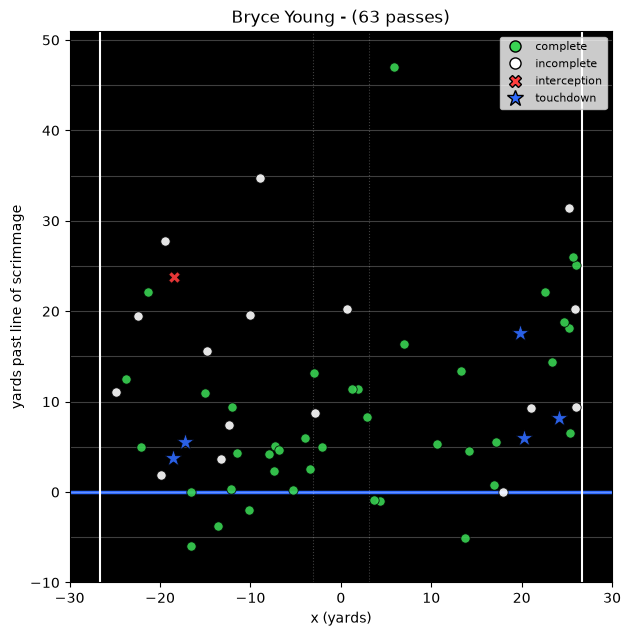

In [64]:
# # --- every route target ---
# ax = plot_routes(routes, f'{routes["name"].iloc[0]} - ({count(routes, "route_id")} routes)')
# ax.legend(handles=route_legend, loc='upper right', fontsize=8)
# plt.show()

# # --- every carry ---
# ax = plot_carries(carries, f'{carries["name"].iloc[0]} - ({count(carries, "carry_id")} carries)')
# ax.legend(handles=carry_legend, loc='upper right', fontsize=8)
# plt.show()

# --- every pass (passes is already one row per pass, so just len(), not the route/carry count() helper) ---
ax = plot_passes(passes, f'{passes["name"].iloc[0]} - ({len(passes)} passes)')
ax.legend(handles=pass_legend, loc='upper right', fontsize=8)
plt.show()

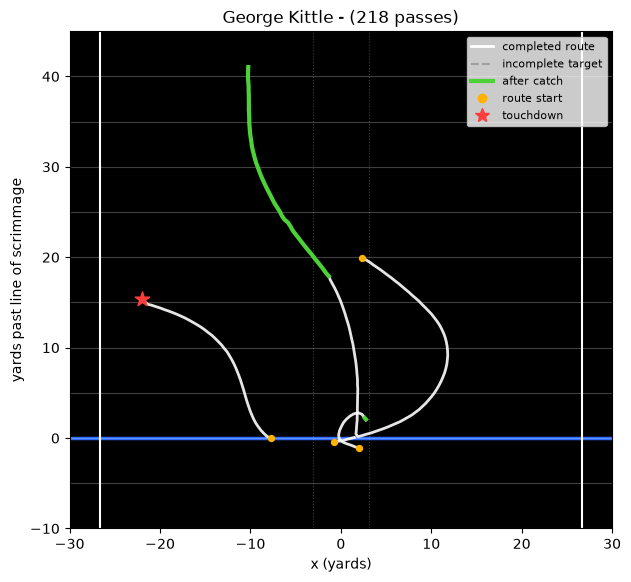

In [65]:
ax = plot_routes(routes, f'{routes["name"].iloc[0]} - ({len(routes)} passes)')
ax.legend(handles=route_legend, loc='upper right', fontsize=8)
plt.show()

# Matching next_gen_scrapy charts (passes/carries/routes) to pbp

`get_passes`/`get_carries`/`get_routes` have no `play_id` - each chart is just a set of dots/lines for one player-game, with no ordering tying a specific dot to a specific play. Matching them to `pbp` is an assignment problem, not a join, solved here in three steps:

1. **Game**: exact. The chart's numeric `game_id` (e.g. `2026091302`) equals `pbp['old_game_id']`.
2. **Player**: exact. `nfl.load_players()` gives an `esb_id` -> `gsis_id` crosswalk, and `gsis_id` is exactly `pbp['passer_player_id']` / `rusher_player_id` / `receiver_player_id`.
3. **Individual play**: approximate. Within a (game, player), bucket by outcome (touchdown / interception / complete / incomplete - whichever the chart guarantees are all drawn), then solve optimal 1:1 assignment (Hungarian algorithm) minimizing `|pbp yardage - chart y_coord|`. Both are already measured from the line of scrimmage, so this works even when a route or carry line is drawn starting behind the LOS - only the chart's absolute `y_coord` matters, never the line's own start point.

Validated against real 2026 data: median residual ~0.5-1.1 yards for passes/carries/routes, with `pass_location` sign independently confirming the matches are real (not noise). Routes are the least reliable of the three - NGS's own target/reception counts don't always equal nflverse's for the same player-game.


In [82]:
import numpy as np
from scipy.optimize import linear_sum_assignment

CHART_ID_COL = {"pass": "passer_player_id", "carry": "rusher_player_id", "route": "receiver_player_id"}
CHART_PLAY_TYPE = {"pass": "pass", "carry": "run", "route": "pass"}


def _game_id_crosswalk(pbp_pd):
    """NGS chart game_id (numeric, e.g. '2026091302') == pbp['old_game_id']."""
    return pbp_pd[["game_id", "old_game_id"]].drop_duplicates().set_index("old_game_id")["game_id"]


def _esb_to_gsis(esb_ids):
    players = nfl.load_players().to_pandas().dropna(subset=["esb_id"]).drop_duplicates(subset=["esb_id"])
    return players.set_index("esb_id")["gsis_id"].reindex(esb_ids)


def _hungarian_match(pbp_sub, chart_sub, pbp_col, chart_col):
    """Optimal 1:1 assignment minimizing |pbp_col - chart_col|. Handles unequal set sizes -
    excess rows on the larger side are simply left unmatched. Rows with a NaN match-value (e.g.
    a handful of pbp plays have null air_yards) are dropped first - they can't be matched by
    yardage and linear_sum_assignment can't accept NaN in the cost matrix anyway."""
    pbp_sub = pbp_sub[pbp_sub[pbp_col].notna()]
    chart_sub = chart_sub[chart_sub[chart_col].notna()]
    if len(pbp_sub) == 0 or len(chart_sub) == 0:
        return []
    pbp_sub = pbp_sub.reset_index()
    chart_sub = chart_sub.reset_index()
    cost = np.abs(pbp_sub[pbp_col].to_numpy(dtype=float)[:, None]
                  - chart_sub[chart_col].to_numpy(dtype=float)[None, :])
    rows, cols = linear_sum_assignment(cost)
    return [(pbp_sub.loc[r, "index"], chart_sub.loc[c, "index"], cost[r, c]) for r, c in zip(rows, cols)]


def match_chart_to_pbp(chart_df, pbp_pd, kind):
    """
    Match a next_gen_scrapy chart DataFrame (from get_passes / get_carries / get_routes) to the
    pbp rows for the same plays. There is no shared play id between the two, so this:

      1. joins the game exactly: chart['game_id'] (NGS's numeric id) == pbp['old_game_id']
      2. resolves the player exactly via an esb_id -> gsis_id crosswalk (nfl.load_players())
      3. within each (game, player), buckets rows by outcome - touchdown / interception /
         complete / incomplete for passes, touchdown / other for carries - and solves an optimal
         assignment (Hungarian algorithm) minimizing |pbp yardage - chart y_coord|. Both are
         already measured from the line of scrimmage (y=0 in the chart, air_yards/yards_gained
         in pbp), so no adjustment is needed even when a route or carry line starts behind the
         LOS - only the chart's absolute y_coord matters, never the line's own start point.

    kind: 'pass' | 'carry' | 'route'

    Returns one row per matched play: kind, bucket, game_id, play_id, residual (yards), plus the
    matched chart row's own columns prefixed with chart_ (chart_name, chart_x_coord/chart_y_coord
    or chart_catch_y, chart_pass_type/chart_route_type, chart_touchdown, etc. - whichever columns
    that chart kind has). These are embedded directly rather than returned as an index to look up
    later: for carry/route the match happens against an aggregated one-row-per-carry/-route table
    (not the raw one-row-per-point chart_df), so an index into that table can't be used to slice
    chart_df itself - keeping the matched columns inline avoids that whole class of mistake.
    Sort by residual - large residuals (roughly >3 yards) are the ones worth treating with
    suspicion.

    Caveats:
      - pass: TOUCHDOWN / INTERCEPTION / COMPLETE are guaranteed 1:1 with pbp (every one is drawn
        on the chart). INCOMPLETE is not - NGS charts don't draw every incompletion - so some
        incomplete pbp attempts will simply go unmatched.
      - carry: every carry is guaranteed drawn, so counts should line up exactly with the
        rusher's run plays for that game.
      - route: the least reliable of the three. NGS's own target/reception counts for a route
        chart don't always equal nflverse's target/reception counts for the same player-game
        (they come from different charting sources), so bucket sizes can mismatch and some
        matches will be low-confidence. Treat route matches more skeptically than pass/carry.
    """
    assert kind in ("pass", "carry", "route")
    id_col = CHART_ID_COL[kind]
    play_type = CHART_PLAY_TYPE[kind]

    gmap = _game_id_crosswalk(pbp_pd)
    chart = chart_df.copy()
    chart["game_id_nflverse"] = chart["game_id"].astype(str).map(gmap)
    chart["gsis_id"] = chart["esb_id"].map(_esb_to_gsis(chart["esb_id"].unique()))

    if kind == "carry":
        chart_reduced = (
            chart.sort_values("point")
            .groupby(["game_id_nflverse", "gsis_id", "carry_id"])
            .agg(name=("name", "first"), team=("team", "first"), position=("position", "first"),
                 y_coord=("y_coord", "last"), touchdown=("touchdown", "first"),
                 fumble_lost=("fumble_lost", "first"), gain_class=("gain_class", "first"))
            .reset_index()
        )
    elif kind == "route":
        def _catch_y(g):
            g = g.sort_values("point")
            pre = g[g["segment"] != "after_catch"]
            return pre["y_coord"].iloc[-1] if len(pre) else g["y_coord"].iloc[-1]

        chart_reduced = (
            chart.groupby(["game_id_nflverse", "gsis_id", "route_id"])
            .apply(lambda g: pd.Series({
                "name": g["name"].iloc[0], "team": g["team"].iloc[0], "position": g["position"].iloc[0],
                "catch_y": _catch_y(g), "route_type": g["route_type"].iloc[0], "touchdown": g["touchdown"].iloc[0],
            }), include_groups=False)
            .reset_index()
        )
    else:
        chart_reduced = chart

    pbp_typed = pbp_pd[pbp_pd["play_type"] == play_type]

    matches = []
    for (game_id, gsis_id), grp_chart in chart_reduced.groupby(["game_id_nflverse", "gsis_id"]):
        if pd.isna(game_id) or pd.isna(gsis_id):
            continue
        grp_pbp = pbp_typed[(pbp_typed["game_id"] == game_id) & (pbp_typed[id_col] == gsis_id)]

        if kind == "pass":
            buckets = {
                "TOUCHDOWN": (grp_pbp[grp_pbp["pass_touchdown"] == 1],
                              grp_chart[grp_chart["pass_type"] == "TOUCHDOWN"], "air_yards", "y_coord"),
                "INTERCEPTION": (grp_pbp[grp_pbp["interception"] == 1],
                                  grp_chart[grp_chart["pass_type"] == "INTERCEPTION"], "air_yards", "y_coord"),
                "COMPLETE": (grp_pbp[(grp_pbp["complete_pass"] == 1) & (grp_pbp["pass_touchdown"] == 0)],
                             grp_chart[grp_chart["pass_type"] == "COMPLETE"], "air_yards", "y_coord"),
                "INCOMPLETE": (grp_pbp[grp_pbp["incomplete_pass"] == 1],
                               grp_chart[grp_chart["pass_type"] == "INCOMPLETE"], "air_yards", "y_coord"),
            }
        elif kind == "carry":
            buckets = {
                "TOUCHDOWN": (grp_pbp[grp_pbp["rush_touchdown"] == 1],
                              grp_chart[grp_chart["touchdown"] == True], "yards_gained", "y_coord"),
                "OTHER": (grp_pbp[grp_pbp["rush_touchdown"] != 1],
                          grp_chart[grp_chart["touchdown"] != True], "yards_gained", "y_coord"),
            }
        else:  # route
            buckets = {
                "TOUCHDOWN": (grp_pbp[grp_pbp["pass_touchdown"] == 1],
                              grp_chart[grp_chart["touchdown"] == True], "air_yards", "catch_y"),
                "COMPLETE": (grp_pbp[(grp_pbp["complete_pass"] == 1) & (grp_pbp["pass_touchdown"] == 0)],
                             grp_chart[(grp_chart["route_type"] == "COMPLETE") & (grp_chart["touchdown"] != True)],
                             "air_yards", "catch_y"),
                "INCOMPLETE": (grp_pbp[grp_pbp["complete_pass"] == 0],
                               grp_chart[grp_chart["route_type"] == "INCOMPLETE"], "air_yards", "catch_y"),
            }

        for bucket, (p_sub, c_sub, pcol, ccol) in buckets.items():
            for pbp_idx, chart_idx, resid in _hungarian_match(p_sub, c_sub, pcol, ccol):
                chart_row = chart_reduced.loc[chart_idx].to_dict()
                matches.append(dict(
                    kind=kind, bucket=bucket, game_id=game_id,
                    play_id=pbp_pd.loc[pbp_idx, "play_id"], residual=round(float(resid), 2),
                    **{f"chart_{k}": v for k, v in chart_row.items() if k not in ("game_id_nflverse", "gsis_id")}
                ))

    return pd.DataFrame(matches)

In [83]:
# demo: match George Kittle's chart routes (already loaded above as `routes`) to their pbp rows.
# NOTE: routes_with_pbp is one row per ROUTE (a summary table for pbp attribution/analysis), not one row
# per point along the route - plot_routes needs the latter, so don't pass this into plot_routes directly.
# To visualize a specific matched route, filter the original multi-point `routes` dataframe instead.
route_matches = match_chart_to_pbp(routes, pbp_pd, "route")
routes_with_pbp = route_matches.rename(columns={
    "chart_name": "name", "chart_team": "team", "chart_position": "position",
    "chart_route_type": "route_type", "chart_catch_y": "catch_y",
})
routes_with_pbp = routes_with_pbp.merge(pbp_pd.drop(columns=["name"]), on=["game_id", "play_id"], how="left")
routes_with_pbp.sort_values("residual", ascending=False).head(10)

,kind,bucket,game_id,play_id,residual,chart_route_id,name,team,position,catch_y,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
1,route,COMPLETE,2026_02_MIA_SF,1906.0,14.37,1,George Kittle,SF,TE,2.63,...,0.0,0.0,2.588320,0.324937,4.856207,2.0,1.000000,1.000000,0.425350,57.464993
0,route,TOUCHDOWN,2026_02_MIA_SF,1988.0,3.38,3,George Kittle,SF,TE,15.38,...,0.0,0.0,1.702143,NaN,NaN,NaN,NaN,NaN,0.361844,63.815573
2,route,COMPLETE,2026_02_MIA_SF,2335.0,1.93,2,George Kittle,SF,TE,0.07,...,0.0,0.0,-0.603156,1.275709,3.222039,3.0,0.696828,0.546031,0.486227,51.377323
3,route,COMPLETE,2026_02_MIA_SF,2856.0,1.55,4,George Kittle,SF,TE,17.45,...,0.0,0.0,2.080643,0.428566,5.767082,3.0,1.000000,1.000000,0.423436,57.656357


In [84]:
kittle = routes_with_pbp[routes_with_pbp['receiver_player_name'] == 'G.Kittle']
kittle

,kind,bucket,game_id,play_id,residual,chart_route_id,name,team,position,catch_y,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,route,TOUCHDOWN,2026_02_MIA_SF,1988.0,3.38,3,George Kittle,SF,TE,15.38,...,0.0,0.0,1.702143,NaN,NaN,NaN,NaN,NaN,0.361844,63.815573
1,route,COMPLETE,2026_02_MIA_SF,1906.0,14.37,1,George Kittle,SF,TE,2.63,...,0.0,0.0,2.588320,0.324937,4.856207,2.0,1.000000,1.000000,0.425350,57.464993
2,route,COMPLETE,2026_02_MIA_SF,2335.0,1.93,2,George Kittle,SF,TE,0.07,...,0.0,0.0,-0.603156,1.275709,3.222039,3.0,0.696828,0.546031,0.486227,51.377323
3,route,COMPLETE,2026_02_MIA_SF,2856.0,1.55,4,George Kittle,SF,TE,17.45,...,0.0,0.0,2.080643,0.428566,5.767082,3.0,1.000000,1.000000,0.423436,57.656357


In [85]:
# demo: match Bryce Young's chart passes (already loaded above as `passes`) to their pbp rows
pass_matches = match_chart_to_pbp(passes, pbp_pd, "pass")
print(pass_matches["bucket"].value_counts())
print(pass_matches["residual"].describe())

# rename chart_* columns back to plain names so plot_passes (which expects x_coord/y_coord/pass_type/name) works,
# then attach the matched pbp columns. pbp_pd has its own unrelated 'name' column, so drop it to avoid a
# name_x/name_y collision - the chart's player name is the one we want here.
passes_with_pbp = pass_matches.rename(columns={
    "chart_name": "name", "chart_position": "position", "chart_team": "team",
    "chart_pass_type": "pass_type", "chart_x_coord": "x_coord", "chart_y_coord": "y_coord",
})
passes_with_pbp = passes_with_pbp.merge(pbp_pd.drop(columns=["name"]), on=["game_id", "play_id"], how="left")
passes_with_pbp.sort_values("residual", ascending=False).head(10)

bucket
COMPLETE        40
INCOMPLETE      16
TOUCHDOWN        5
INTERCEPTION     1
Name: count, dtype: int64
count    62.000000
mean      1.646774
std       2.273500
min       0.020000
25%       0.375000
50%       0.930000
75%       1.782500
max      10.570000
Name: residual, dtype: float64


,kind,bucket,game_id,play_id,residual,chart_game_id,chart_season,chart_season_type,chart_week,team,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
54,pass,INCOMPLETE,2026_02_CAR_ATL,607.0,10.57,2026092000,2026,REG,2,CAR,...,0.0,1.0,-0.575858,0.423526,3.630203,2.0,0.999491,0.180799,0.648202,35.179806
19,pass,COMPLETE,2026_01_CHI_CAR,4279.0,9.18,2026091300,2026,REG,1,CAR,...,0.0,0.0,1.364240,0.780551,4.161622,2.0,0.779847,0.230537,0.855851,14.414859
57,pass,INCOMPLETE,2026_02_CAR_ATL,936.0,8.81,2026092000,2026,REG,2,CAR,...,0.0,1.0,-0.694547,NaN,NaN,NaN,NaN,NaN,0.958287,4.171330
41,pass,COMPLETE,2026_02_CAR_ATL,1551.0,6.64,2026092000,2026,REG,2,CAR,...,0.0,1.0,1.721723,0.438419,5.736875,3.0,1.000000,1.000000,0.463537,53.646258
60,pass,INCOMPLETE,2026_02_CAR_ATL,2352.0,6.60,2026092000,2026,REG,2,CAR,...,0.0,1.0,-0.400472,NaN,NaN,NaN,NaN,NaN,0.887165,11.283547
33,pass,TOUCHDOWN,2026_02_CAR_ATL,2859.0,5.61,2026092000,2026,REG,2,CAR,...,0.0,1.0,1.801906,NaN,NaN,NaN,NaN,NaN,0.348576,65.142384
10,pass,COMPLETE,2026_01_CHI_CAR,2072.0,3.19,2026091300,2026,REG,1,CAR,...,0.0,0.0,3.423302,0.362844,5.615872,3.0,1.000000,1.000000,0.651338,34.866244
21,pass,COMPLETE,2026_01_CHI_CAR,4398.0,3.10,2026091300,2026,REG,1,CAR,...,1.0,0.0,1.403033,0.303560,3.336308,1.0,1.000000,1.000000,0.893275,10.672528
42,pass,COMPLETE,2026_02_CAR_ATL,1576.0,2.87,2026092000,2026,REG,2,CAR,...,0.0,1.0,1.437745,0.850907,5.848484,5.0,1.000000,1.000000,0.437822,56.217802
48,pass,COMPLETE,2026_02_CAR_ATL,2646.0,2.55,2026092000,2026,REG,2,CAR,...,0.0,1.0,2.457267,0.132352,3.523926,1.0,0.992008,0.966601,0.957450,4.255027


In [92]:
evans = passes_with_pbp[passes_with_pbp['receiver_player_name'] == 'T.McMillan']

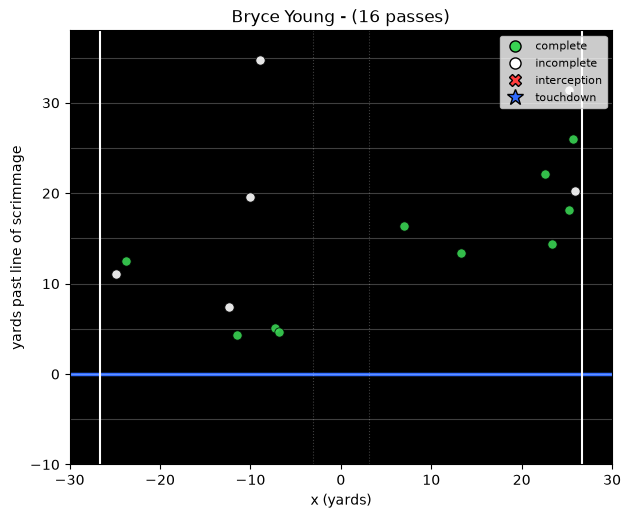

In [93]:
ax = plot_passes(evans, f'{evans["name"].iloc[0]} - ({len(evans)} passes)')
ax.legend(handles=pass_legend, loc='upper right', fontsize=8)
plt.show()

In [90]:
evans

,kind,bucket,game_id,play_id,residual,chart_game_id,chart_season,chart_season_type,chart_week,team,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
1,pass,TOUCHDOWN,2026_01_CHI_CAR,4523.0,1.95,2026091300,2026,REG,1,CAR,...,0.0,0.0,2.318046,0.993960,1.942208,2.0,0.736167,0.270541,0.899194,10.080552
2,pass,INTERCEPTION,2026_01_CHI_CAR,2460.0,1.79,2026091300,2026,REG,1,CAR,...,0.0,0.0,-0.445732,0.989984,8.569049,3.0,1.000000,1.000000,0.957633,4.236662
4,pass,COMPLETE,2026_01_CHI_CAR,200.0,0.15,2026091300,2026,REG,1,CAR,...,1.0,0.0,2.421463,0.711445,2.063250,3.0,1.000000,1.000000,0.615924,38.407636
7,pass,COMPLETE,2026_01_CHI_CAR,1321.0,0.94,2026091300,2026,REG,1,CAR,...,1.0,0.0,1.065497,0.227741,3.754870,2.0,1.000000,0.960403,0.483700,51.630017
9,pass,COMPLETE,2026_01_CHI_CAR,2008.0,1.81,2026091300,2026,REG,1,CAR,...,0.0,0.0,-0.144434,0.799006,7.844954,6.0,0.624765,0.526093,0.453601,54.639882
15,pass,COMPLETE,2026_01_CHI_CAR,3474.0,0.41,2026091300,2026,REG,1,CAR,...,0.0,0.0,1.353754,0.239912,4.143101,2.0,0.999391,0.993668,0.647047,35.295331
16,pass,COMPLETE,2026_01_CHI_CAR,3545.0,0.51,2026091300,2026,REG,1,CAR,...,0.0,0.0,-0.077315,0.725198,3.472042,2.0,0.687927,0.390482,0.797346,20.265448
19,pass,COMPLETE,2026_01_CHI_CAR,4279.0,9.18,2026091300,2026,REG,1,CAR,...,0.0,0.0,1.364240,0.780551,4.161622,2.0,0.779847,0.230537,0.855851,14.414859
35,pass,COMPLETE,2026_02_CAR_ATL,208.0,0.49,2026092000,2026,REG,2,CAR,...,1.0,1.0,0.504845,0.659063,4.279607,3.0,0.795135,0.087560,0.637766,36.223429
42,pass,COMPLETE,2026_02_CAR_ATL,1576.0,2.87,2026092000,2026,REG,2,CAR,...,0.0,1.0,1.437745,0.850907,5.848484,5.0,1.000000,1.000000,0.437822,56.217802


KeyError: 'y_coord'

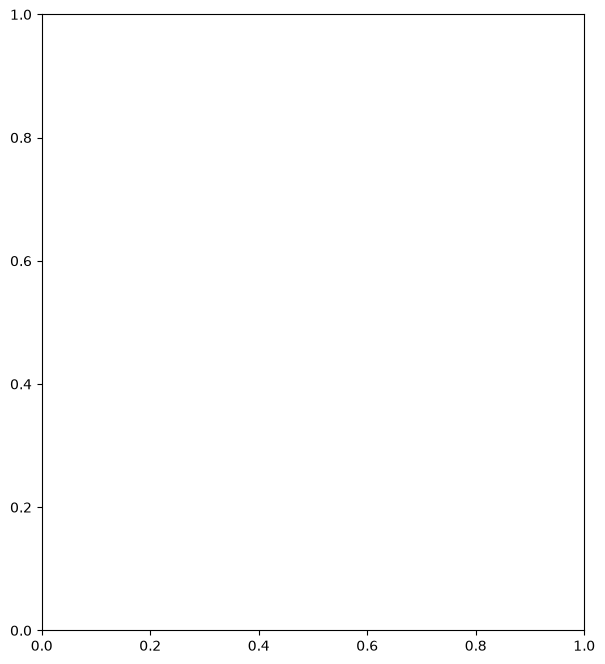

In [91]:
ax = plot_routes(kittle, f'{kittle["name"].iloc[0]} - ({len(kittle)} passes)')
ax.legend(handles=route_legend, loc='upper right', fontsize=8)
plt.show()